### PCVK CM

## Anggota Kelompok
- Dedy Bayu
- Rizqi Fauzan

### Importing and Connecting Drive

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
# from google.colab.patches import cv2_imshow

# from google.colab import drive
# drive.mount('/content/drive')

## Bagian A

1. Tampilkan histogram tiap citra dan analisis distribusi intensitasnya.

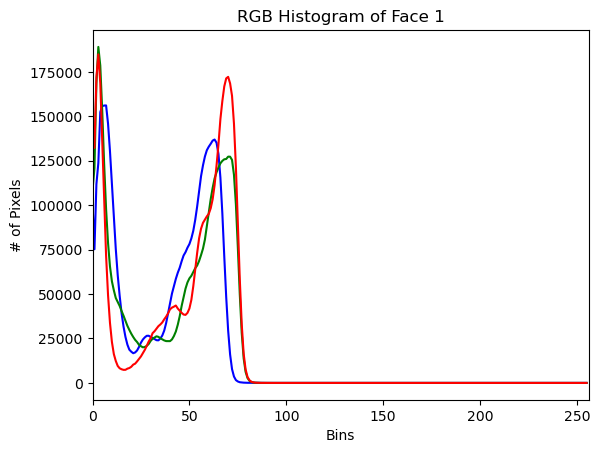

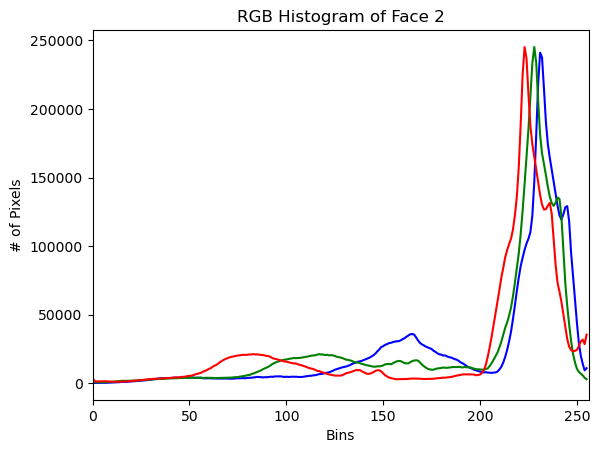

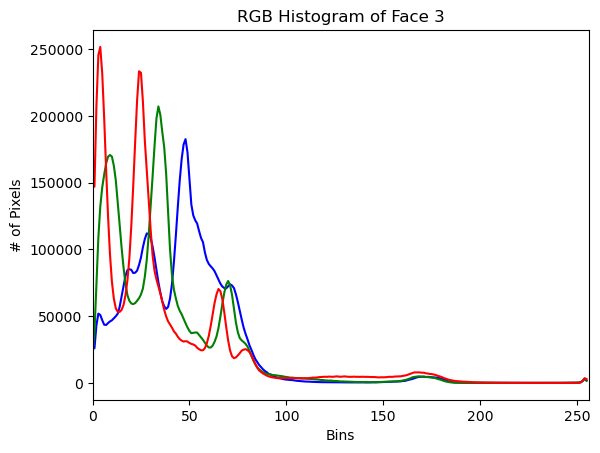

In [5]:
face1 = cv.imread('face1.jpg')
face2 = cv.imread('face2.jpg')
face3 = cv.imread('face3.jpg')

# Function to plot RGB histograms
def plot_rgb_histogram(image, title):
    color = ('b','g','r')
    plt.figure()
    plt.title(title)
    plt.xlabel("Bins")
    plt.ylabel("# of Pixels")
    for i,col in enumerate(color):
        histr = cv.calcHist([image],[i],None,[256],[0,256])
        plt.plot(histr,color = col)
        plt.xlim([0,256])
    plt.show()

# Plot RGB histograms for each face image
plot_rgb_histogram(face1, "RGB Histogram of Face 1")
plot_rgb_histogram(face2, "RGB Histogram of Face 2")
plot_rgb_histogram(face3, "RGB Histogram of Face 3")

2. Terapkan transformasi brightness dan contrast (linear/log brightness).
- Tentukan nilai b (brightness) dan a (contrast) yang sesuai agar wajah tampak
natural.

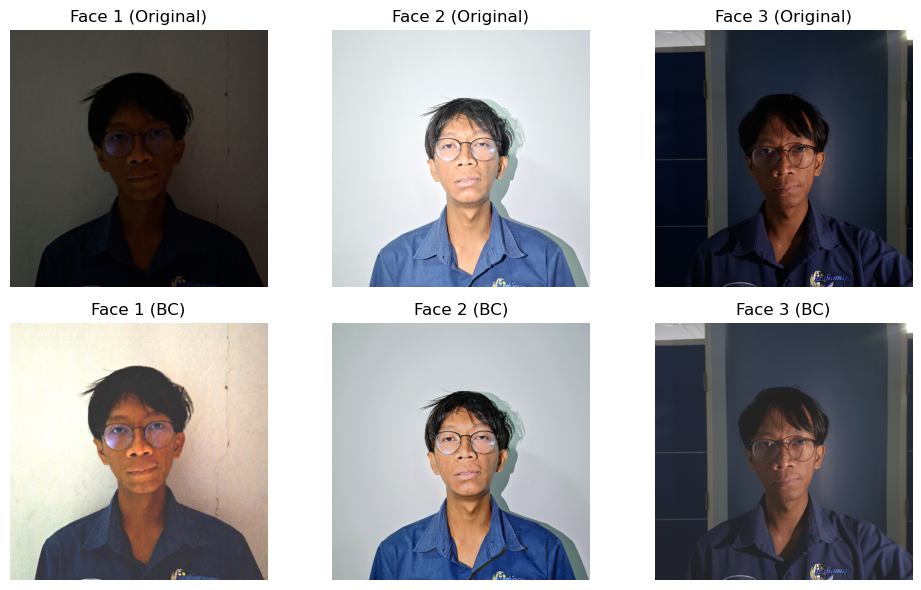

In [6]:
# Values for face1 (adjust as needed)
alpha1 = 3  # contrast
beta1 = 45    # brightness
face1_bc = cv.convertScaleAbs(face1, alpha=alpha1, beta=beta1)

# Values for face2 (adjust as needed)
alpha2 = 1.1  # contrast
beta2 = -55    # brightness
face2_bc = cv.convertScaleAbs(face2, alpha=alpha2, beta=beta2)

# Values for face3 (adjust as needed)
alpha3 = 0.9  # contrast
beta3 = 30    # brightness
face3_bc = cv.convertScaleAbs(face3, alpha=alpha3, beta=beta3)

# Display the results using matplotlib with a smaller figure size
plt.figure(figsize=(10, 6)) # Adjust figure size as needed

# Display original images
plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(face1, cv.COLOR_BGR2RGB))
plt.title("Face 1 (Original)")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(face2, cv.COLOR_BGR2RGB))
plt.title("Face 2 (Original)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(face3, cv.COLOR_BGR2RGB))
plt.title("Face 3 (Original)")
plt.axis('off')

# Display brightness and contrast adjusted images
plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(face1_bc, cv.COLOR_BGR2RGB))
plt.title("Face 1 (BC)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(face2_bc, cv.COLOR_BGR2RGB))
plt.title("Face 2 (BC)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv.cvtColor(face3_bc, cv.COLOR_BGR2RGB))
plt.title("Face 3 (BC)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.show()

3. Lakukan histogram equalization untuk memperbaiki sebaran kontras.
- Bandingkan hasil visual dan histogram sebelum–sesudah.

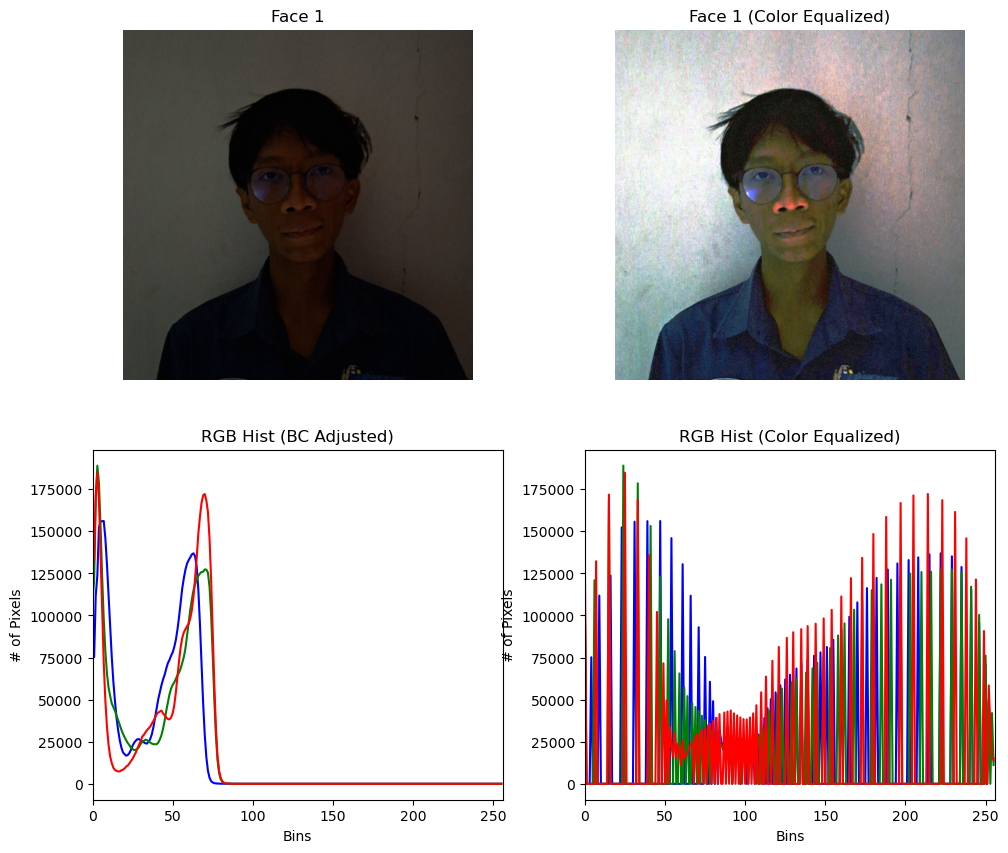

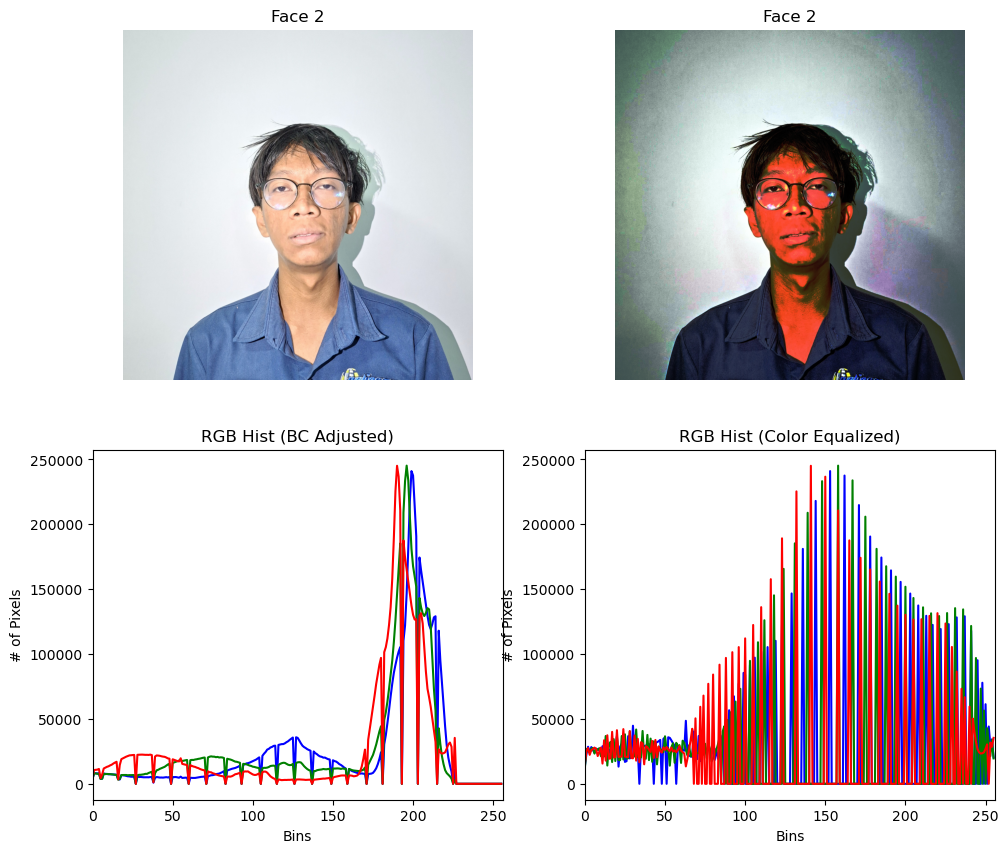

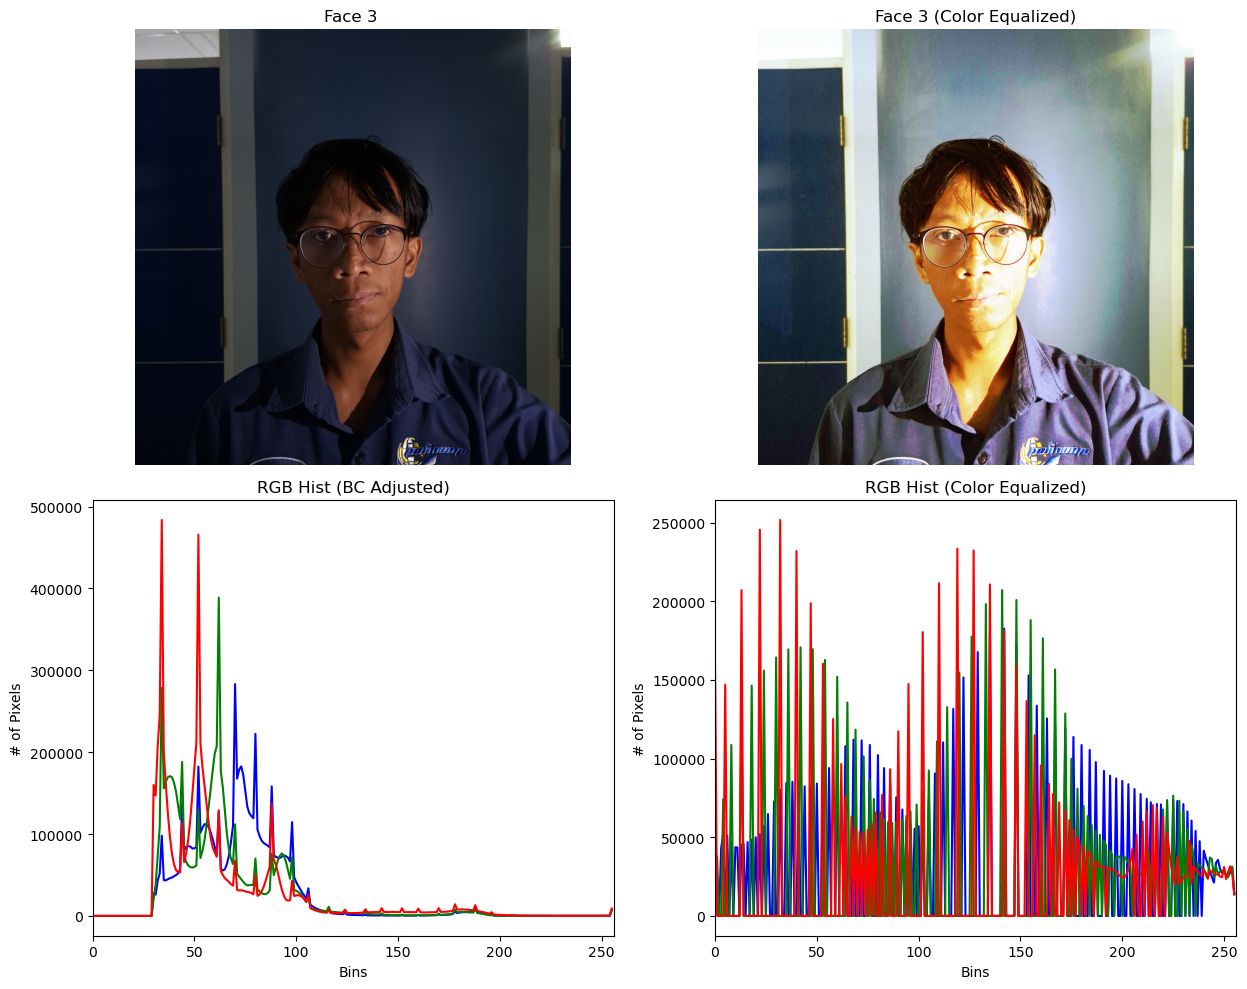

In [7]:
# Perform histogram equalization on each color channel (B, G, R)

# Split the BC adjusted images into channels
b1, g1, r1 = cv.split(face1)
b2, g2, r2 = cv.split(face2)
b3, g3, r3 = cv.split(face3)

# Apply histogram equalization to each channel
b1_he = cv.equalizeHist(b1)
g1_he = cv.equalizeHist(g1)
r1_he = cv.equalizeHist(r1)

b2_he = cv.equalizeHist(b2)
g2_he = cv.equalizeHist(g2)
r2_he = cv.equalizeHist(r2)

b3_he = cv.equalizeHist(b3)
g3_he = cv.equalizeHist(g3)
r3_he = cv.equalizeHist(r3)

# Merge the equalized channels back into a color image
face1_he_color = cv.merge((b1_he, g1_he, r1_he))
face2_he_color = cv.merge((b2_he, g2_he, r2_he))
face3_he_color = cv.merge((b3_he, g3_he, r3_he))

# Function to plot RGB histograms
def plot_rgb_histogram(image, title, subplot_index):
    if image is None:
        print(f"Cannot plot histogram for {title} as the image was not loaded.")
        return
    color = ('b','g','r')
    plt.subplot(subplot_index)
    plt.title(title)
    plt.xlabel("Bins")
    plt.ylabel("# of Pixels")
    for i,col in enumerate(color):
        histr = cv.calcHist([image],[i],None,[256],[0,256])
        plt.plot(histr,color = col)
        plt.xlim([0,256])


# Display the original, BC adjusted, and color equalized images and their histograms horizontally

# face 1
plt.figure(figsize=(18, 10)) # Adjust figure size as needed for horizontal display

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(face1, cv.COLOR_BGR2RGB))
plt.title("Face 1")
plt.axis('off')
plot_rgb_histogram(face1, "RGB Hist (BC Adjusted)", 235) # Subplot for BC hist

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(face1_he_color, cv.COLOR_BGR2RGB))
plt.title("Face 1 (Color Equalized)")
plt.axis('off')
plot_rgb_histogram(face1_he_color, "RGB Hist (Color Equalized)", 236) # Subplot for Equalized hist

# face 2
plt.figure(figsize=(18, 10)) # New figure for Face 2 and Face 3

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(face2, cv.COLOR_BGR2RGB))
plt.title("Face 2")
plt.axis('off')
plot_rgb_histogram(face2_bc, "RGB Hist (BC Adjusted)", 235) # Subplot for BC hist

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(face2_he_color, cv.COLOR_BGR2RGB))
plt.title("Face 2")
plt.axis('off')
plot_rgb_histogram(face2_he_color, "RGB Hist (Color Equalized)", 236) # Subplot for Equalized hist

# Face 3
plt.figure(figsize=(18, 10)) # New figure for Face 3

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(face3, cv.COLOR_BGR2RGB))
plt.title("Face 3 ")
plt.axis('off')
plot_rgb_histogram(face3_bc, "RGB Hist (BC Adjusted)", 235) # Subplot for BC hist

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(face3_he_color, cv.COLOR_BGR2RGB))
plt.title("Face 3 (Color Equalized)")
plt.axis('off')
plot_rgb_histogram(face3_he_color, "RGB Hist (Color Equalized)", 236) # Subplot for Equalized hist


plt.tight_layout()
plt.show()

4. Terapkan filter spasial:
- Low-pass filter untuk menghaluskan noise kulit wajah.
-  High-pass atau Laplacian filter untuk menajamkan tepi mata dan bibir.

In [8]:
face1_lp = cv.GaussianBlur(face1, (3, 3), 0)
face2_lp = cv.GaussianBlur(face2, (3, 3), 0)
face3_lp = cv.GaussianBlur(face3, (3, 3), 0)

# Apply High-pass filter (using Laplacian) for sharpening edges
# ksize (e.g., 1) can be adjusted
face1_hp = cv.Laplacian(face1, cv.CV_64F, ksize=1)
face2_hp = cv.Laplacian(face2, cv.CV_64F, ksize=1)
face3_hp = cv.Laplacian(face3, cv.CV_64F, ksize=1)

# Convert the high-pass output back to uint8 for display
face1_hp = cv.convertScaleAbs(face1_hp)
face2_hp = cv.convertScaleAbs(face2_hp)
face3_hp = cv.convertScaleAbs(face3_hp)

5. Implementasikan Floyd–Steinberg Dithering untuk menurunkan kedalaman warna
wajah (bit-depth 4–6 bit), lalu analisis bagaimana efeknya terhadap detail dan ekspresi
wajah.

In [ ]:
def floyd_steinberg_dither_rgb(img):
    """Dithering Floyd–Steinberg untuk gambar RGB 24-bit."""
    dithered = img.copy().astype(np.float32)

    h, w, c = dithered.shape

    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = dithered[y, x].copy()

            new_pixel = np.round(old_pixel / 255) * 255
            dithered[y, x] = new_pixel

            error = old_pixel - new_pixel

            dithered[y, x + 1]     += error * 7 / 16
            dithered[y + 1, x - 1] += error * 3 / 16
            dithered[y + 1, x]     += error * 5 / 16
            dithered[y + 1, x + 1] += error * 1 / 16

    return np.clip(dithered, 0, 255).astype(np.uint8)

face1_dithered = floyd_steinberg_dither_rgb(face1)
face2_dithered = floyd_steinberg_dither_rgb(face2)
face3_dithered = floyd_steinberg_dither_rgb(face3)

# face 1
plt.figure(figsize=(15, 8)) # Adjust figure size as needed for horizontal display

plt.subplot(2, 3, 2)
plt.imshow(cv.cvtColor(face1, cv.COLOR_BGR2RGB))
plt.title("Face 1")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(face1_he_color, cv.COLOR_BGR2RGB))
plt.title("Face 1 (Dithering)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Bagian B

1. Bagaimana perubahan nilai brightness dan contrast memengaruhi hasil histogram wajah gelap?
- brightness tinggi untuk mencerahkan yang image gelap
- kontras 1-2 untuk melebarkan sebaran warna

2. Apakah histogram equalization selalu memperbaiki detail wajah? Jelaskan alasannya dengan contoh hasil Anda.
- tidak selalu hanya memerbaiki image dengan kontras rendah

3. Bandingkan hasil low-pass dan high-pass filter pada area wajah, bagian mana yang paling terpengaruh?

- laplacian memiliki perubahan paling tampak

4. Mengapa proses dithering bisa mempertegas atau justru mengaburkan ekspresi wajah?
- Dapat Mempertegas Ekspresi: Pada kedalaman bit yang tepat dan dengan pola dithering yang efektif, dithering dapat menciptakan ilusi detail dan tekstur di area yang sebelumnya memiliki gradasi halus. Ini bisa membuat fitur-fitur kunci seperti mata dan mulut (yang penting untuk ekspresi) terlihat lebih jelas karena kontras di sekitarnya meningkat.

5. Berdasarkan hasil percobaan Anda, kombinasi teknik mana yang paling efektif untuk meningkatkan readability fitur wajah sebelum tahap deteksi?

- Asli -> Filtering → Brightness/Contrast (BC) → Histogram Equalization (HE) → Dithering

## Bagian C

Gunakan struktur kode seperti:
```
import cv2, numpy as np, matplotlib.pyplot as plt
img = cv2.imread('face1.jpg', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Brightness & Contrast
b, a = 30, 1.2
img_bc = cv2.convertScaleAbs(gray, alpha=a, beta=b)
# Histogram Equalization
img_he = cv2.equalizeHist(img_bc)
# Spatial Filtering (contoh High-pass)
kernel_hp = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
img_hp = cv2.filter2D(img_he, -1, kernel_hp)
```

Kemudian tampilkan hasil 4 tahap (asli → BC → HE → Filter → Dithered).

### Brightness & Contrast

In [ ]:
def adjust_brightness_contrast(img, brightness=30, contrast=1.2):
    """Tingkatkan kontras dan kecerahan."""
    adjusted = np.clip(img * contrast + brightness, 0, 255).astype(np.uint8)
    return adjusted

### Equalization

In [ ]:
def equalize_hist(img):
    return cv.equalizeHist(img)

### Filtering

In [ ]:
def filter_img(img):
    kernel = np.array([
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ])
    filter_img = cv.filter2D(img, -1, kernel)
    filter_img = cv.normalize(filter_img, None, 0, 255, cv.NORM_MINMAX)
    return filter_img


### Dithering

In [ ]:
def floyd_steinberg_dither(img):
    """Dithering Floyd–Steinberg untuk grayscale 8-bit."""
    dithered = img.astype(np.float32)
    h, w = dithered.shape
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = dithered[y, x]
            new_pixel = 0 if old_pixel < 128 else 255
            dithered[y, x] = new_pixel
            error = old_pixel - new_pixel
            # Sebarkan error ke piksel sekitar
            dithered[y, x + 1] += error * 7 / 16
            dithered[y + 1, x - 1] += error * 3 / 16
            dithered[y + 1, x] += error * 5 / 16
            dithered[y + 1, x + 1] += error * 1 / 16
    return np.clip(dithered, 0, 255).astype(np.uint8)



### Show Image Func

In [ ]:
def show_images(titles, images, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap=cmap)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

### Urutan terbaik


=== Kombinasi 01: Brightness/Contrast -> Histogram Equalization -> High-Pass Filter -> Dithering ===


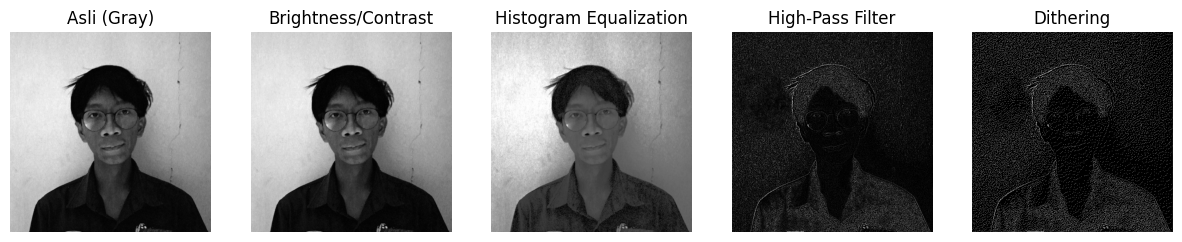


=== Kombinasi 02: Brightness/Contrast -> Histogram Equalization -> Dithering -> High-Pass Filter ===


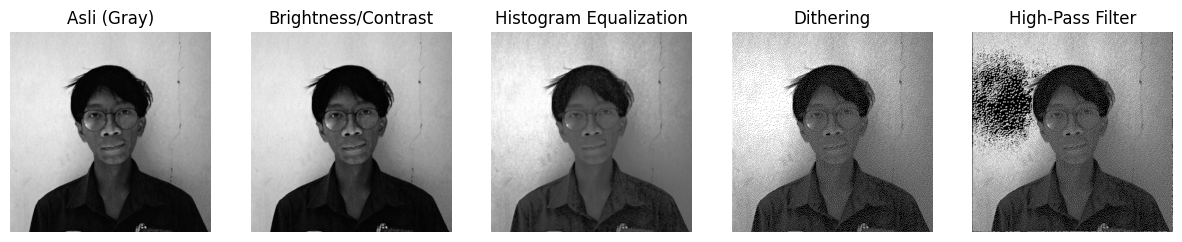


=== Kombinasi 03: Brightness/Contrast -> High-Pass Filter -> Histogram Equalization -> Dithering ===


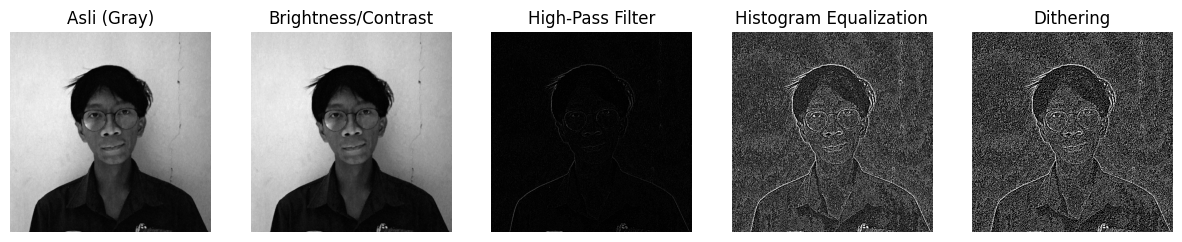


=== Kombinasi 04: Brightness/Contrast -> High-Pass Filter -> Dithering -> Histogram Equalization ===


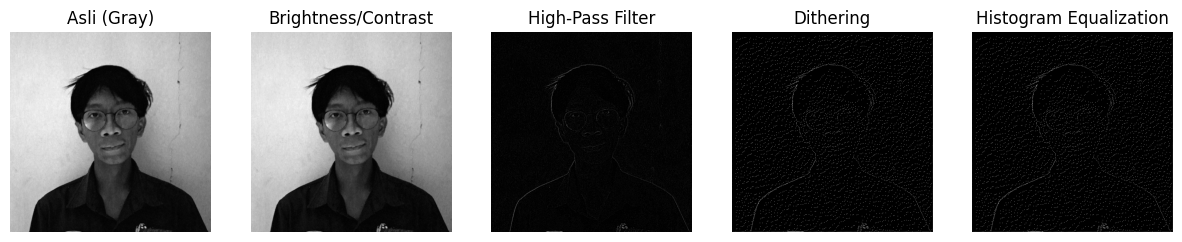


=== Kombinasi 05: Brightness/Contrast -> Dithering -> Histogram Equalization -> High-Pass Filter ===


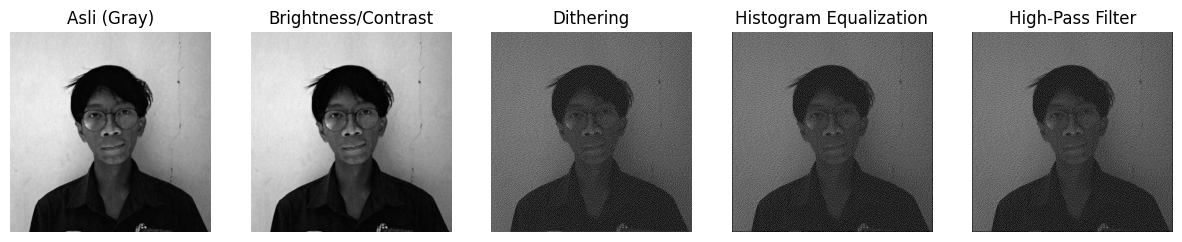


=== Kombinasi 06: Brightness/Contrast -> Dithering -> High-Pass Filter -> Histogram Equalization ===


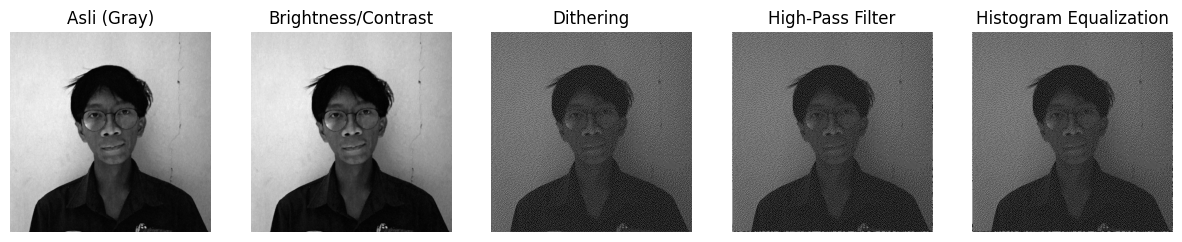


=== Kombinasi 07: Histogram Equalization -> Brightness/Contrast -> High-Pass Filter -> Dithering ===


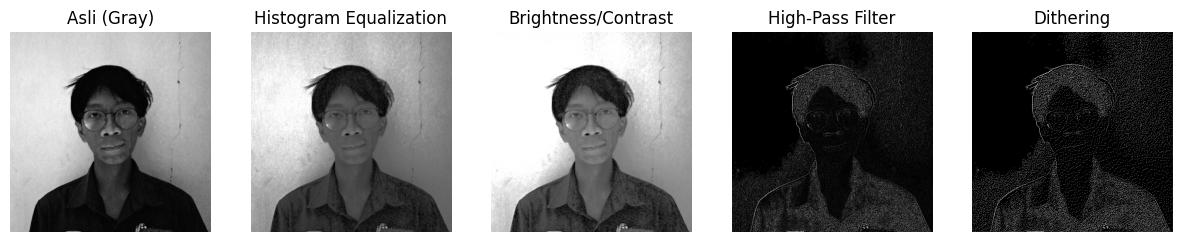


=== Kombinasi 08: Histogram Equalization -> Brightness/Contrast -> Dithering -> High-Pass Filter ===


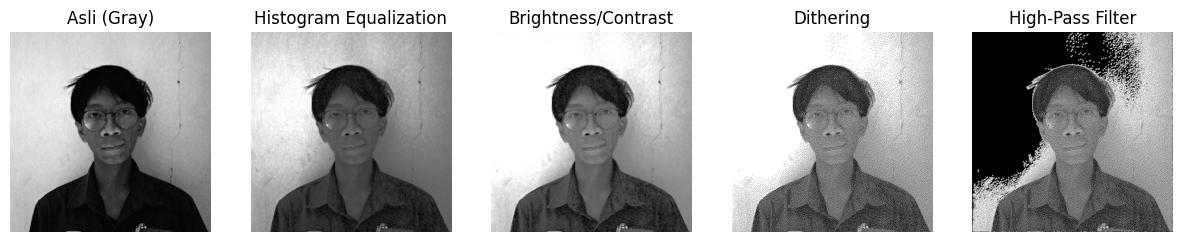


=== Kombinasi 09: Histogram Equalization -> High-Pass Filter -> Brightness/Contrast -> Dithering ===


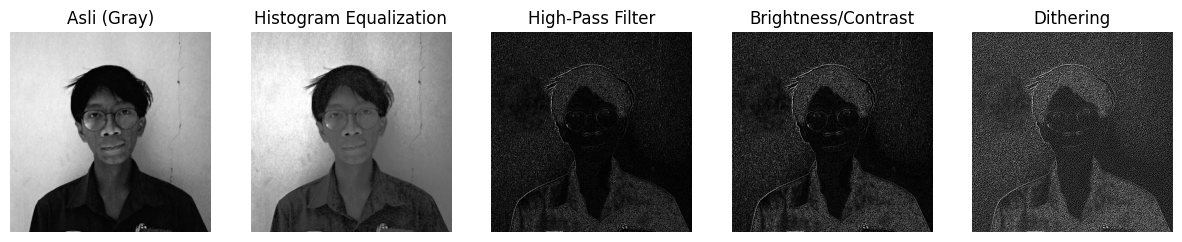


=== Kombinasi 10: Histogram Equalization -> High-Pass Filter -> Dithering -> Brightness/Contrast ===


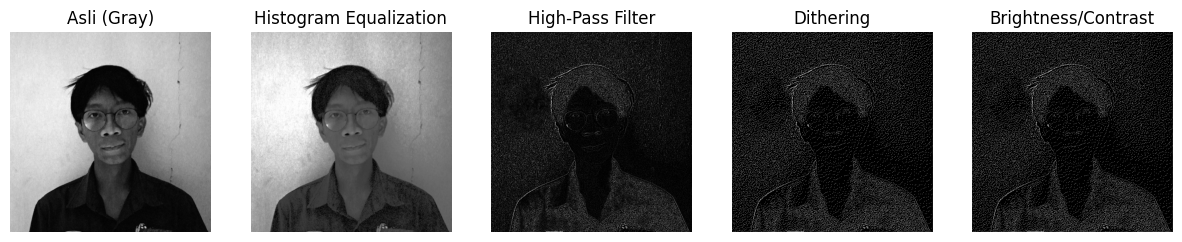


=== Kombinasi 11: Histogram Equalization -> Dithering -> Brightness/Contrast -> High-Pass Filter ===


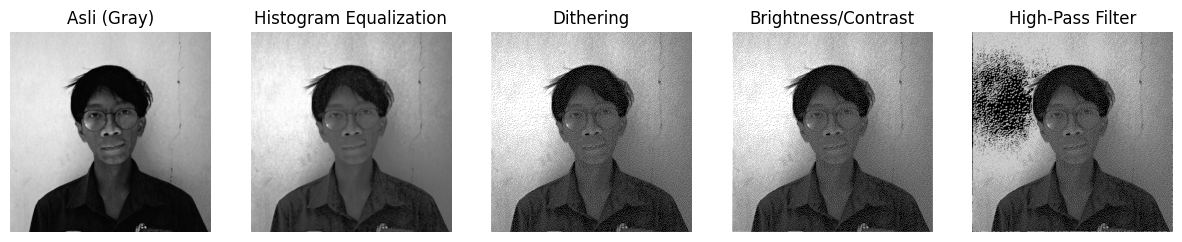


=== Kombinasi 12: Histogram Equalization -> Dithering -> High-Pass Filter -> Brightness/Contrast ===


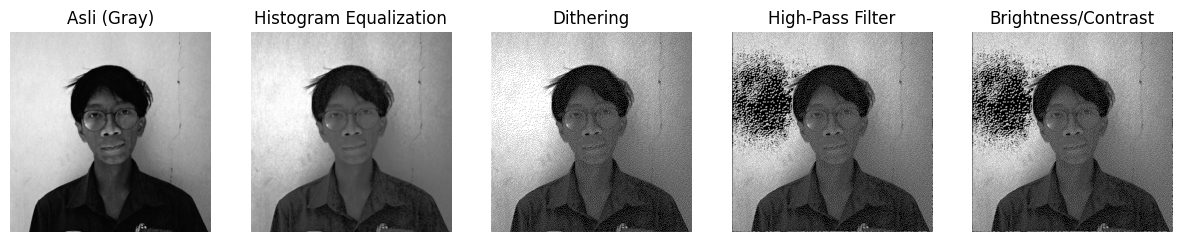


=== Kombinasi 13: High-Pass Filter -> Brightness/Contrast -> Histogram Equalization -> Dithering ===


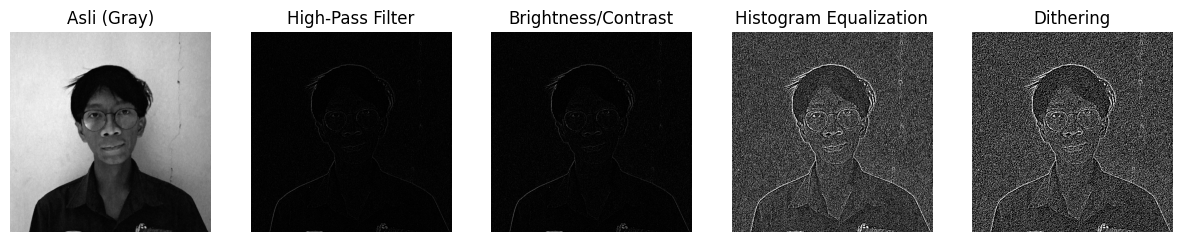


=== Kombinasi 14: High-Pass Filter -> Brightness/Contrast -> Dithering -> Histogram Equalization ===


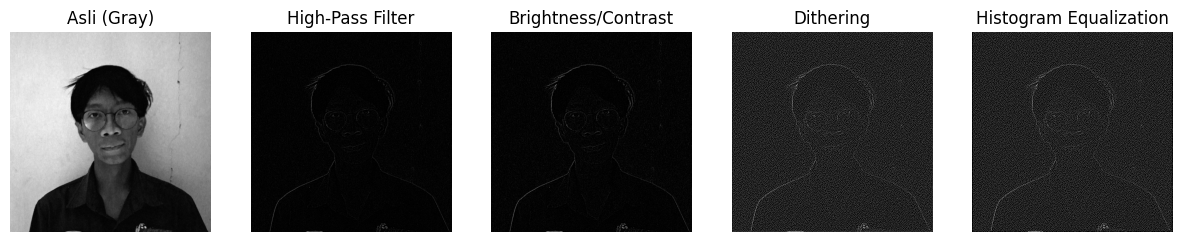


=== Kombinasi 15: High-Pass Filter -> Histogram Equalization -> Brightness/Contrast -> Dithering ===


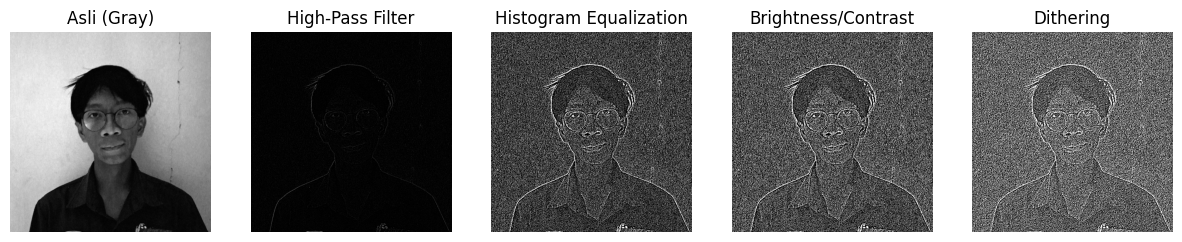


=== Kombinasi 16: High-Pass Filter -> Histogram Equalization -> Dithering -> Brightness/Contrast ===


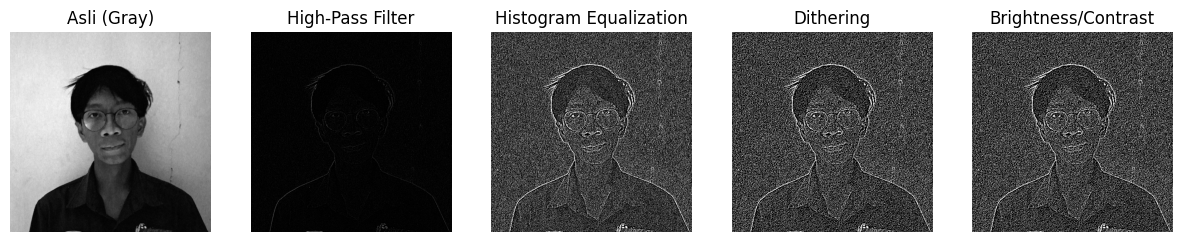


=== Kombinasi 17: High-Pass Filter -> Dithering -> Brightness/Contrast -> Histogram Equalization ===


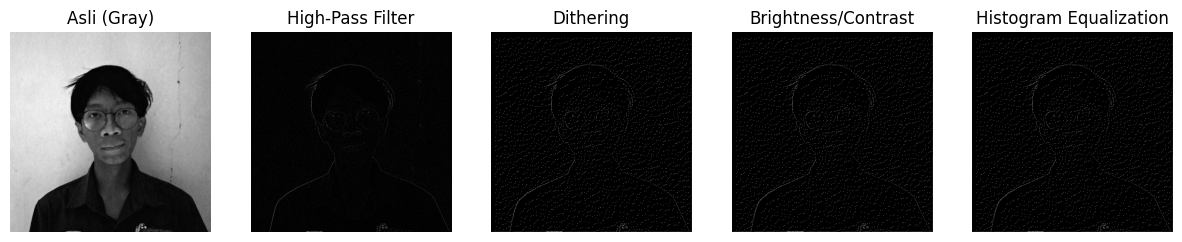


=== Kombinasi 18: High-Pass Filter -> Dithering -> Histogram Equalization -> Brightness/Contrast ===


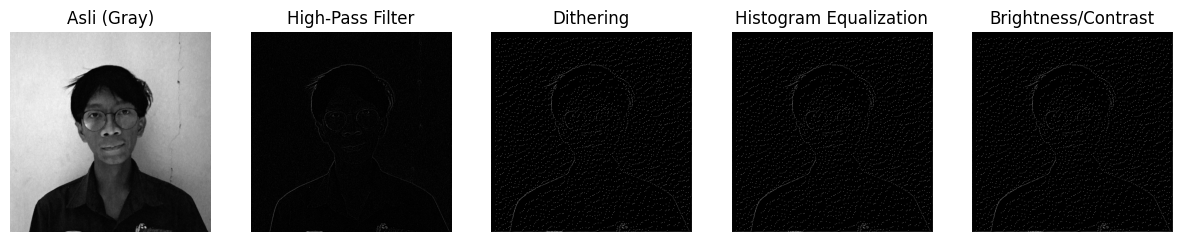


=== Kombinasi 19: Dithering -> Brightness/Contrast -> Histogram Equalization -> High-Pass Filter ===


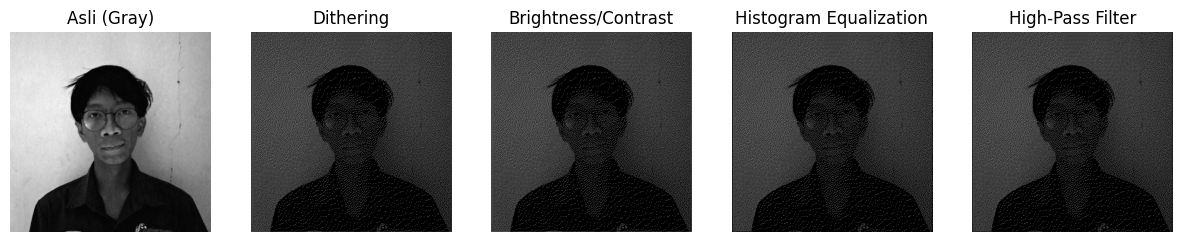


=== Kombinasi 20: Dithering -> Brightness/Contrast -> High-Pass Filter -> Histogram Equalization ===


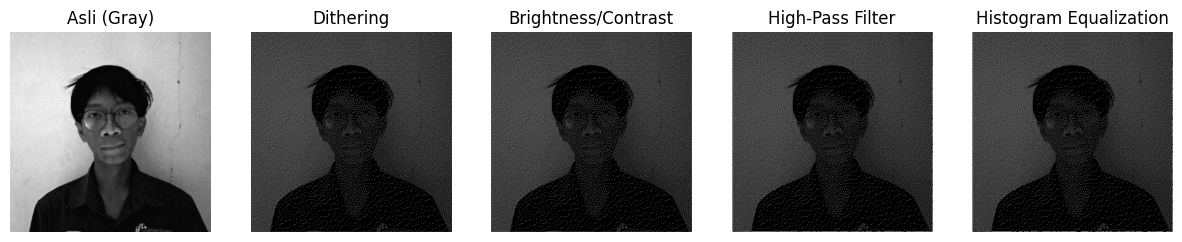


=== Kombinasi 21: Dithering -> Histogram Equalization -> Brightness/Contrast -> High-Pass Filter ===


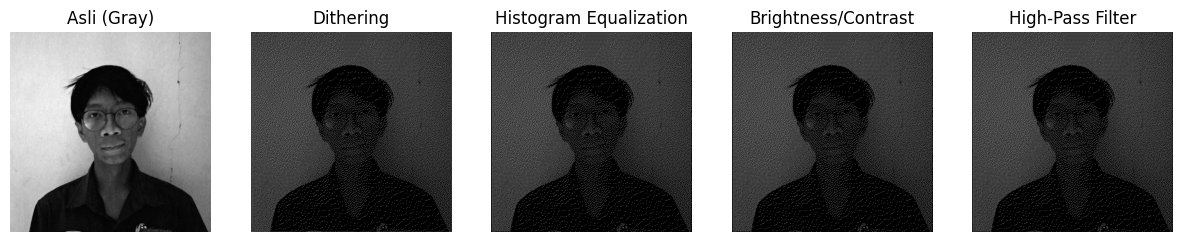


=== Kombinasi 22: Dithering -> Histogram Equalization -> High-Pass Filter -> Brightness/Contrast ===


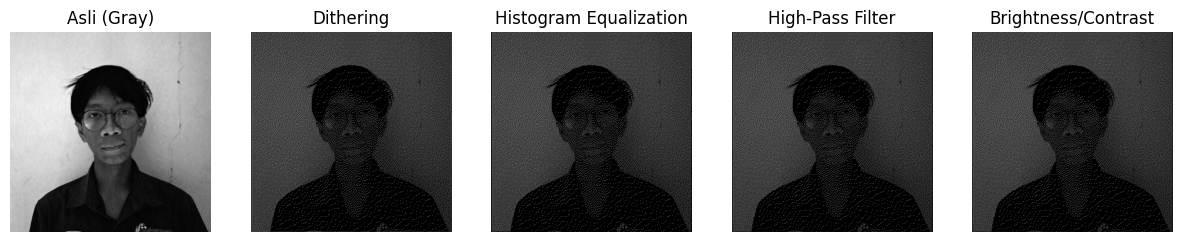


=== Kombinasi 23: Dithering -> High-Pass Filter -> Brightness/Contrast -> Histogram Equalization ===


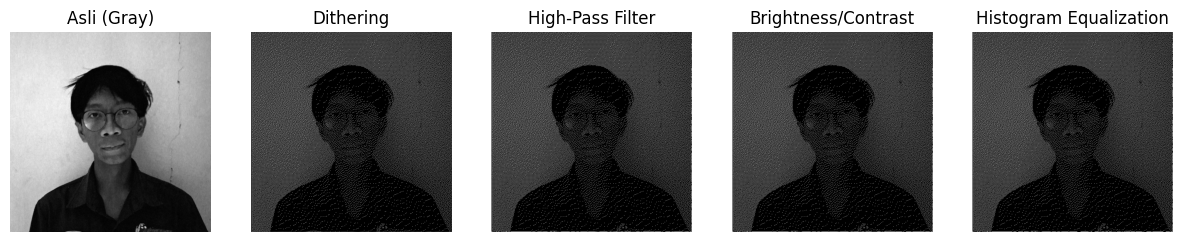


=== Kombinasi 24: Dithering -> High-Pass Filter -> Histogram Equalization -> Brightness/Contrast ===


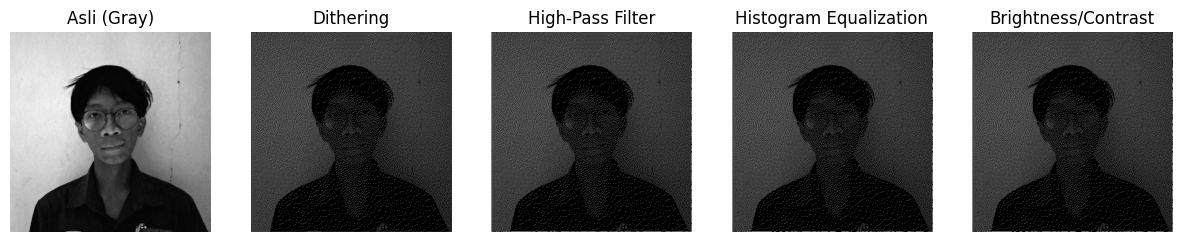

In [ ]:
import itertools
import cv2 as cv

face1_asli = face1
face1_resized = cv.resize(face1_asli, (500, 500), interpolation=cv.INTER_AREA)
face1_gray = cv.cvtColor(face1_resized, cv.COLOR_BGR2GRAY)

# --- Daftar operasi ---
operations = [
    ("Brightness/Contrast", lambda img: adjust_brightness_contrast(img, brightness=30, contrast=1.2)),
    ("Histogram Equalization", equalize_hist),
    ("High-Pass Filter", filter_img),
    ("Dithering", floyd_steinberg_dither)
]

# --- Semua urutan (4! = 24 kombinasi) ---
all_orders = list(itertools.permutations(operations))

# --- Jalankan setiap urutan ---
for idx, ops in enumerate(all_orders, start=1):
    img = face1_gray.copy()
    titles = ["Asli (Gray)"]
    imgs = [img]
    seq_names = []

    # Terapkan tiap operasi sesuai urutan
    for name, func in ops:
        img = func(img)
        imgs.append(img)
        seq_names.append(name)

    titles += seq_names

    print(f"\n=== Kombinasi {idx:02d}: {' -> '.join(seq_names)} ===")
    show_images(titles, imgs)


## Bagian D - Analisis Akhir & Kesimpulan

Tuliskan 1 halaman analisis:

1. Urutan proses terbaik untuk menghasilkan wajah paling siap recognition
- 1. Filtering → 2. Brightness/Contrast (BC) → 3. Histogram Equalization (HE) → 4. Dithering

2. Perbandingan nilai PSNR antara citra asli yang memiliki pencahanyaan baik dan hasil pra-
pemrosesan

### func Gaussian Blur

In [ ]:
def gaussian_blur(image, kernel_size):
    return cv.GaussianBlur(image, (kernel_size, kernel_size), 0)

func PSNR

In [ ]:
def psnr(original, processed):
    mse = np.mean((original.astype(np.float32) - processed.astype(np.float32)) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    return 10 * np.log10((max_pixel ** 2) / mse)

Compare

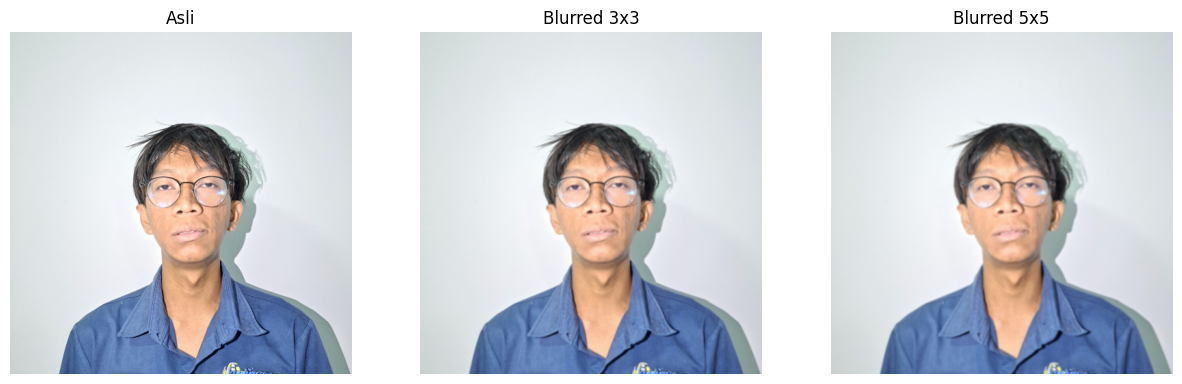

In [ ]:
face2_asli = face2
face2_resized = cv.resize(face2_asli, (500, 500), interpolation=cv.INTER_AREA)
face2_rgb = cv.cvtColor(face2_resized, cv.COLOR_BGR2RGB)

face2_blur3 = gaussian_blur(face2_rgb, 3)
face2_blur5 = gaussian_blur(face2_rgb, 5)

show_images(
    ['Asli','Blurred 3x3', 'Blurred 5x5'],
    [face2_rgb, face2_blur3, face2_blur5]
)

In [ ]:
# print(f'PSNR asli: {psnr(face2_rgb, face2_rgb)}')
print(f'PSNR blurred 3x3: {psnr(face2_rgb, face2_blur3)}')
print(f'PSNR blurred 5x5: {psnr(face2_rgb, face2_blur5)}')

PSNR blurred 3x3: 35.136863708496094
PSNR blurred 5x5: 32.926055908203125


3. Rekomendasi metode peningkatan kualitas wajah untuk sistem pengenalan wajah real-time
- Kombinasi Histogram Equalization (HE) → Brightness/Contrast (BC)
Alasan:

Histogram Equalization (HE) menormalkan distribusi intensitas sehingga detail wajah di area gelap atau terang menjadi lebih jelas.

Penyesuaian Brightness/Contrast setelah HE memberikan hasil visual yang lebih stabil terhadap perubahan pencahayaan real-time (misalnya perbedaan intensitas lampu atau bayangan).

Tambah Bilateral Filter :
Untuk menjaga tepi wajah dan fitur penting (mata, hidung, mulut) sambil mengurangi noise.